### MBA BI BIG DATA T8 
#### Machine Learning: Tópicos Avançados
##### Wandeilson Ferreira 
##### Analise de combustiveis 

##### Importando as bibliotecas e carregando o dataset

In [144]:
# Importando as bibliotecas do projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [145]:
#Carregando o dataset
df = pd.read_csv('base/Valor_combustivel_Brasil_2020_2025.csv', sep=';')  

C:\Users\WFerreira\AppData\Local\Temp\ipykernel_7716\1797371891.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('base/Valor_combustivel_Brasil_2020_2025.csv', sep=';')


##### Inspeção Inicial dos Dados

In [146]:
df.head()

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,SE,SP,GUARULHOS,AUTO POSTO SAKAMOTO LTDA,49.051.667/0001-02,RODOVIA PRESIDENTE DUTRA,S/N,"KM 210,5-SENT SP/RJ",BONSUCESSO,07178-580,GASOLINA,03/01/2020,"4,399",NaN,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.
1,SE,SP,GUARULHOS,AUTO POSTO SAKAMOTO LTDA,49.051.667/0001-02,RODOVIA PRESIDENTE DUTRA,S/N,"KM 210,5-SENT SP/RJ",BONSUCESSO,07178-580,ETANOL,03/01/2020,"3,199",NaN,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.
2,SE,SP,GUARULHOS,AUTO POSTO SAKAMOTO LTDA,49.051.667/0001-02,RODOVIA PRESIDENTE DUTRA,S/N,"KM 210,5-SENT SP/RJ",BONSUCESSO,07178-580,DIESEL S10,03/01/2020,"3,899",NaN,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.
3,SE,SP,GUARULHOS,AUTO POSTO SAKAMOTO LTDA,49.051.667/0001-02,RODOVIA PRESIDENTE DUTRA,S/N,"KM 210,5-SENT SP/RJ",BONSUCESSO,07178-580,GNV,03/01/2020,"2,995",NaN,R$ / m³,PETROBRAS DISTRIBUIDORA S.A.
4,NE,BA,SALVADOR,PETROBRAS DISTRIBUIDORA S.A.,34.274.233/0015-08,RUA EDISTIO PONDE,474,NaN,STIEP,41770-395,GASOLINA,03/01/2020,"4,69","4,1743",R$ / litro,PETROBRAS DISTRIBUIDORA S.A.


In [147]:
df.tail()

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
1048570,SE,RJ,RESENDE,AUTO POSTO MR LTDA.,09.635.291/0001-69,AVENIDA GENERAL AFONSECA,660,NaN,MANEJO,27520-173,GASOLINA ADITIVADA,30/06/2021,"6,559",NaN,R$ / litro,ALESAT
1048571,SE,RJ,RESENDE,AUTO POSTO MR LTDA.,09.635.291/0001-69,AVENIDA GENERAL AFONSECA,660,NaN,MANEJO,27520-173,GASOLINA,30/06/2021,"6,499",NaN,R$ / litro,ALESAT
1048572,NE,BA,SALVADOR,3L COMERCIO DE COMBUSTIVEIS E LUBRIFICANTES LTDA.,07.192.452/0001-61,AVENIDA CARYBE,1290,POSTO,SAO CRISTOVAO,41510-732,GASOLINA,27/06/2021,"5,899",NaN,R$ / litro,RAIZEN
1048573,NE,BA,SALVADOR,3L COMERCIO DE COMBUSTIVEIS E LUBRIFICANTES LTDA.,07.192.452/0001-61,AVENIDA CARYBE,1290,POSTO,SAO CRISTOVAO,41510-732,ETANOL,27/06/2021,"4,899",NaN,R$ / litro,RAIZEN
1048574,NE,BA,SALVADOR,3L COMERCIO DE COMBUSTIVEIS E LUBRIFICANTES LTDA.,07.192.452/0001-61,AVENIDA CARYBE,1290,POSTO,SAO CRISTOVAO,41510-732,DIESEL S10,27/06/2021,"4,699",NaN,R$ / litro,RAIZEN


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype 
---  ------             --------------    ----- 
 0   Regiao - Sigla     1048575 non-null  object
 1   Estado - Sigla     1048575 non-null  object
 2   Municipio          1048575 non-null  object
 3   Revenda            1048575 non-null  object
 4   CNPJ da Revenda    1048575 non-null  object
 5   Nome da Rua        1048575 non-null  object
 6   Numero Rua         1047933 non-null  object
 7   Complemento        251683 non-null   object
 8   Bairro             1045359 non-null  object
 9   Cep                1048575 non-null  object
 10  Produto            1048575 non-null  object
 11  Data da Coleta     1048575 non-null  object
 12  Valor de Venda     1048575 non-null  object
 13  Valor de Compra    156014 non-null   object
 14  Unidade de Medida  1048575 non-null  object
 15  Bandeira           1048575 non-null  object
dtype

In [149]:
df.describe().T

,count,unique,top,freq
Regiao - Sigla,1048575,6,SE,510573
Estado - Sigla,1048575,28,SP,315987
Municipio,1048575,465,SAO PAULO,42089
Revenda,1048575,14586,SIM REDE DE POSTOS LTDA,5857
CNPJ da Revenda,1048575,16802,01.420.327/0001-85,330
Nome da Rua,1048575,9983,AVENIDA BRASIL,9680
Numero Rua,1047933,4653,S/N,110237
Complemento,251683,2743,0,20217
Bairro,1045359,6389,CENTRO,160311
Cep,1048575,11842,46430-000,2344


In [150]:
df.isnull().sum()


Regiao - Sigla            0
Estado - Sigla            0
Municipio                 0
Revenda                   0
CNPJ da Revenda           0
Nome da Rua               0
Numero Rua              642
Complemento          796892
Bairro                 3216
Cep                       0
Produto                   0
Data da Coleta            0
Valor de Venda            0
Valor de Compra      892561
Unidade de Medida         0
Bandeira                  0
dtype: int64

In [151]:
#Criando uma copia do dataframe
novo_df= df.copy()  


In [152]:
# Remover a vírgula e substituir por ponto para fazer a correção:
novo_df['Valor de Venda'] = pd.to_numeric(novo_df['Valor de Venda'].str.replace(',', '.'), errors='coerce')
novo_df['Valor de Venda'] = novo_df['Valor de Venda'].astype(float)

# Remover a vírgula e substituir por ponto para fazer a correção: 
novo_df['Valor de Compra'] = df['Valor de Compra'].astype(str).str.replace(',', '.', regex=False)
# Converter para tipo numérico (float)
novo_df['Valor de Compra'] = pd.to_numeric(df['Valor de Compra'], errors='coerce')
# Substituir os NaNs pela média da coluna
novo_df['Valor de Compra'].fillna(novo_df['Valor de Compra'].mean(), inplace=True)


# Converte a coluna 'Data da Coleta' para formato datetime
novo_df['Data da Coleta'] = pd.to_datetime(novo_df['Data da Coleta'], errors='coerce')



C:\Users\WFerreira\AppData\Local\Temp\ipykernel_7716\2969475814.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  novo_df['Valor de Compra'].fillna(novo_df['Valor de Compra'].mean(), inplace=True)


In [153]:
novo_df.isnull().sum()

Regiao - Sigla            0
Estado - Sigla            0
Municipio                 0
Revenda                   0
CNPJ da Revenda           0
Nome da Rua               0
Numero Rua              642
Complemento          796892
Bairro                 3216
Cep                       0
Produto                   0
Data da Coleta       627574
Valor de Venda            2
Valor de Compra           0
Unidade de Medida         0
Bandeira                  0
dtype: int64

##### Analise dos combustiveis

In [154]:
# Média de preço das combustiveis:
novo_df.groupby('Produto')['Valor de Venda'].mean()


Produto
DIESEL                3.616770
DIESEL S10            3.724362
ETANOL                3.449566
GASOLINA              4.578761
GASOLINA ADITIVADA    5.309279
GNV                   3.281454
Produto                    NaN
Name: Valor de Venda, dtype: float64

In [155]:
#Preço máximo e mínimo por estado/região nos ultimos 5 anos:
novo_df.groupby('Estado - Sigla')['Valor de Venda'].agg(['max', 'min'])

,max,min
Estado - Sigla,,
AC,6.900,3.340
AL,6.399,2.599
AM,6.100,2.979
AP,5.700,2.850
BA,6.999,2.190
CE,6.299,2.679
DF,6.599,2.499
ES,6.999,2.590
Estado - Sigla,NaN,NaN


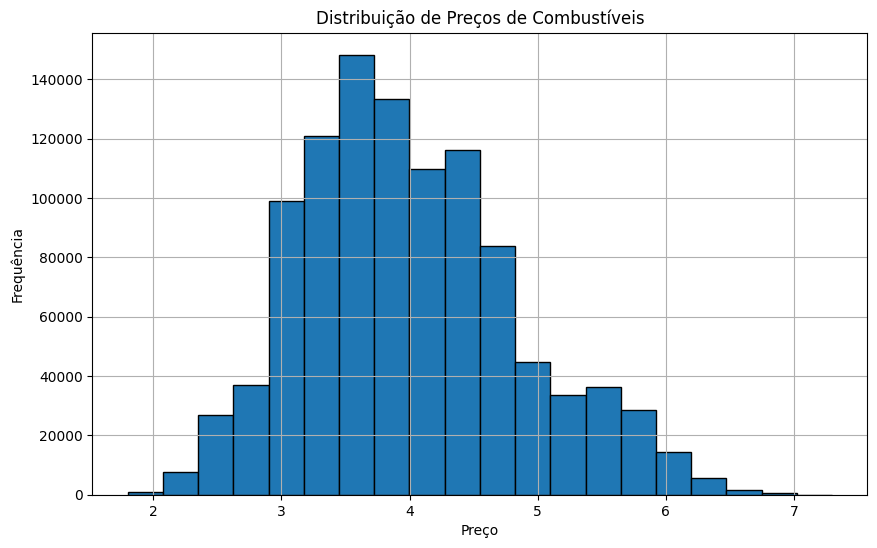

In [ ]:
#Visualização de Dados com Matplotlib
plt.figure(figsize=(10, 6))
plt.hist(novo_df['Valor de Venda'], bins=20, edgecolor='black')
plt.title('Distribuição de Preços de Combustíveis')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

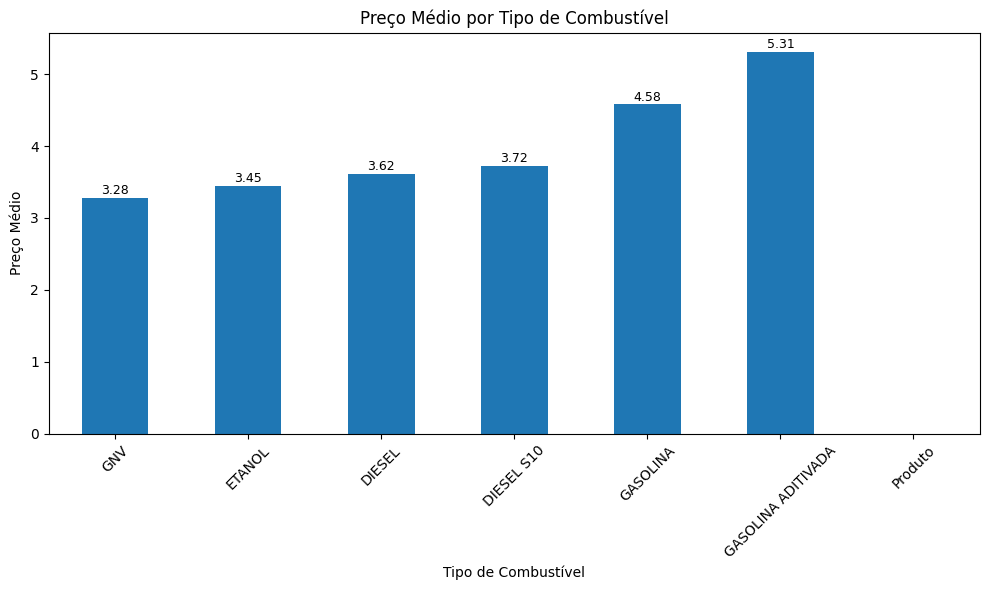

In [162]:
# Comparando o preço medio entre os diferentes tipos de combustiveis
preco_por_tipo = novo_df.groupby('Produto')['Valor de Venda'].mean().sort_values()
plt.figure(figsize=(10, 6))
ax = preco_por_tipo.plot(kind='bar', color='skyblue')
preco_por_tipo.plot(kind='bar')
plt.title('Preço Médio por Tipo de Combustível')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Preço Médio')
plt.xticks(rotation=45)
plt.tight_layout()
for i, valor in enumerate(preco_por_tipo):
    ax.text(i, valor + 0.01, f'{valor:.2f}', ha='center', va='bottom', fontsize=9)

plt.show()


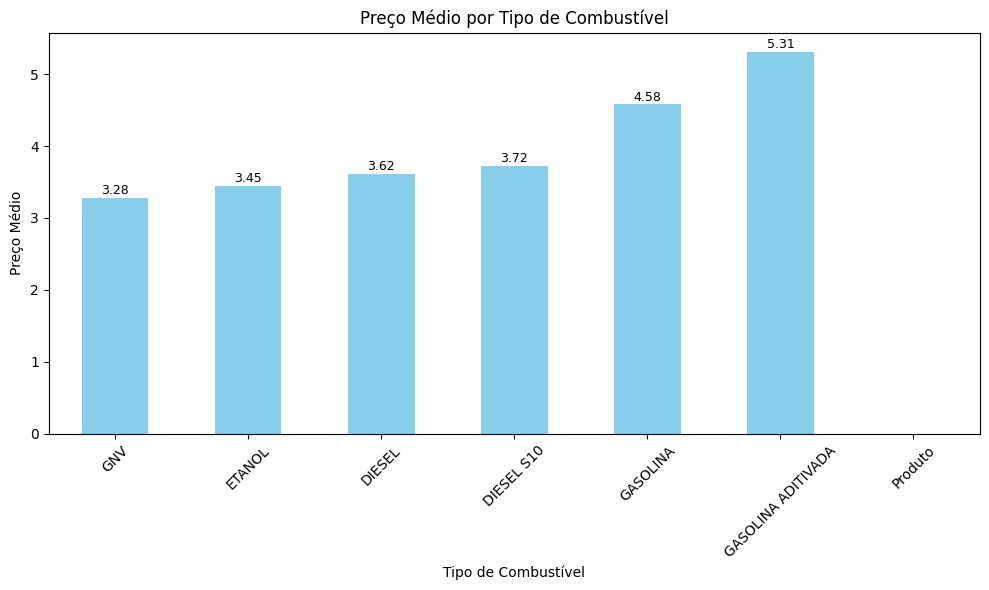

In [160]:
import matplotlib.pyplot as plt

# Agrupamento e cálculo da média
preco_por_tipo = novo_df.groupby('Produto')['Valor de Venda'].mean().sort_values()

# Criar o gráfico
plt.figure(figsize=(10, 6))
ax = preco_por_tipo.plot(kind='bar', color='skyblue')

# Título e eixos
plt.title('Preço Médio por Tipo de Combustível')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Preço Médio')
plt.xticks(rotation=45)
plt.tight_layout()

# Adicionar os valores em cima das barras
for i, valor in enumerate(preco_por_tipo):
    ax.text(i, valor + 0.01, f'{valor:.2f}', ha='center', va='bottom', fontsize=9)

plt.show()